# EDA 8.3: Traffic-Revenue Lead-Lag Analysis

This notebook analyzes whether web traffic appears more closely aligned with same-day Revenue or Revenue several days later. Findings are exploratory signals for forecast feature engineering and should not be treated as causal claims.

## 1. Setup and File Discovery

Locate `web_traffic.csv` and `sales.csv` anywhere under the current working directory. Missing files produce warnings and the notebook continues where possible.

In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('default')
pd.set_option('display.max_columns', 160)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

ROOT = Path.cwd()
FILES = ['web_traffic.csv', 'sales.csv']

def normalize_name(name):
    return re.sub(r'[^a-z0-9]+', '', str(name).strip().lower())

def discover_csvs(root):
    found = {}
    for path in root.rglob('*.csv'):
        key = path.name.lower()
        if key not in found:
            found[key] = path
    return found

csv_files = discover_csvs(ROOT)
selected_paths = {name: csv_files.get(name.lower()) for name in FILES}

file_status = pd.DataFrame([
    {'file': name, 'found': path is not None, 'path': str(path) if path else None}
    for name, path in selected_paths.items()
])
display(file_status)

for name, path in selected_paths.items():
    if path is None:
        warnings.warn(f'{name} was not found. The notebook will continue where possible.')

,file,found,path
0,web_traffic.csv,True,D:\Code\Datathon 2026\datathon-2026-round-1\we...
1,sales.csv,True,D:\Code\Datathon 2026\datathon-2026-round-1\sa...


## 2. Load Web Traffic and Sales Data

Load each available CSV safely with pandas and show the raw schemas.

In [2]:
def safe_read_csv(path, name):
    if path is None:
        return None
    try:
        df = pd.read_csv(path, low_memory=False)
        print(f'Loaded {name}: {df.shape[0]:,} rows x {df.shape[1]:,} columns from {path}')
        return df
    except Exception as exc:
        warnings.warn(f'Could not load {name} from {path}: {exc}')
        return None

traffic_raw = safe_read_csv(selected_paths.get('web_traffic.csv'), 'web_traffic.csv')
sales_raw = safe_read_csv(selected_paths.get('sales.csv'), 'sales.csv')

schema_rows = []
for name, df in [('web_traffic.csv', traffic_raw), ('sales.csv', sales_raw)]:
    if df is not None:
        schema_rows.append({'file': name, 'rows': len(df), 'columns': len(df.columns), 'column_names': ', '.join(map(str, df.columns))})
schema_overview = pd.DataFrame(schema_rows)
display(schema_overview)

Loaded web_traffic.csv: 3,652 rows x 7 columns from D:\Code\Datathon 2026\datathon-2026-round-1\web_traffic.csv
Loaded sales.csv: 3,833 rows x 3 columns from D:\Code\Datathon 2026\datathon-2026-round-1\sales.csv


,file,rows,columns,column_names
0,web_traffic.csv,3652,7,"date, sessions, unique_visitors, page_views, b..."
1,sales.csv,3833,3,"Date, Revenue, COGS"


## 3. Identify Traffic, Date, and Revenue Columns

Column matching normalizes case, spaces, punctuation, and underscores, then uses candidate names and keyword scoring for minor naming differences.

In [3]:
def column_lookup(df):
    if df is None:
        return {}
    return {normalize_name(c): c for c in df.columns}

def find_col(df, candidates=None, include_all=None, include_any=None, exclude_any=None, prefer_numeric=False):
    if df is None:
        return None
    candidates = candidates or []
    include_all = [normalize_name(x) for x in (include_all or [])]
    include_any = [normalize_name(x) for x in (include_any or [])]
    exclude_any = [normalize_name(x) for x in (exclude_any or [])]
    lookup = column_lookup(df)
    for cand in candidates:
        key = normalize_name(cand)
        if key in lookup:
            return lookup[key]
    scored = []
    for col in df.columns:
        key = normalize_name(col)
        if exclude_any and any(x in key for x in exclude_any):
            continue
        if include_all and not all(x in key for x in include_all):
            continue
        if include_any and not any(x in key for x in include_any):
            continue
        score = sum(3 for x in include_all if x in key) + sum(2 for x in include_any if x in key)
        if prefer_numeric and pd.api.types.is_numeric_dtype(df[col]):
            score += 1
        scored.append((score, len(key), col))
    if scored:
        scored.sort(key=lambda x: (-x[0], x[1], str(x[2])))
        return scored[0][2]
    return None

def to_num(s):
    return pd.to_numeric(s, errors='coerce')

def infer_revenue_col(df):
    if df is None:
        return None
    direct = find_col(
        df,
        ['revenue', 'total_revenue', 'sales_amount', 'sales', 'net_sales', 'amount'],
        include_any=['revenue', 'salesamount', 'totalsales', 'netsales'],
        exclude_any=['cost', 'cogs', 'margin', 'profit', 'tax'],
        prefer_numeric=True,
    )
    if direct is not None:
        return direct
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) or to_num(df[c]).notna().mean() > 0.8]
    candidates = []
    for c in numeric_cols:
        key = normalize_name(c)
        if any(x in key for x in ['cost', 'cogs', 'margin', 'profit', 'tax', 'id']):
            continue
        vals = to_num(df[c])
        candidates.append(((vals > 0).mean(), vals.abs().sum(skipna=True), c))
    if candidates:
        candidates.sort(key=lambda x: (-x[0], -x[1], str(x[2])))
        warnings.warn(f'Revenue column was not explicit; using likely numeric revenue column: {candidates[0][2]}')
        return candidates[0][2]
    return None

cols = {}
if traffic_raw is not None:
    cols['traffic_date'] = find_col(traffic_raw, ['date', 'traffic_date', 'visit_date', 'event_date', 'session_date'], include_any=['date', 'day'])
    cols['sessions'] = find_col(traffic_raw, ['sessions', 'session_count', 'visits'], include_any=['sessions', 'sessioncount', 'visits'], prefer_numeric=True)
    cols['page_views'] = find_col(traffic_raw, ['page_views', 'pageviews', 'views', 'page_view_count'], include_any=['pageviews', 'pageviewcount', 'views'], prefer_numeric=True)
    cols['unique_visitors'] = find_col(traffic_raw, ['unique_visitors', 'unique_users', 'users', 'visitors'], include_any=['uniquevisitors', 'uniqueusers', 'users', 'visitors'], exclude_any=['sessions'], prefer_numeric=True)
    cols['bounce_rate'] = find_col(traffic_raw, ['bounce_rate', 'bouncerate', 'bounce_pct', 'bounce_percentage'], include_any=['bouncerate', 'bouncepct', 'bouncepercentage'], prefer_numeric=True)
    cols['session_duration'] = find_col(traffic_raw, ['avg_session_duration_sec', 'avg_session_duration', 'average_session_duration', 'session_duration', 'duration'], include_any=['sessionduration', 'averagesessionduration', 'avgsessionduration', 'duration'], prefer_numeric=True)
if sales_raw is not None:
    cols['sales_date'] = find_col(sales_raw, ['date', 'sales_date', 'order_date', 'revenue_date'], include_any=['date', 'day'])
    cols['revenue'] = infer_revenue_col(sales_raw)

identified_columns = pd.DataFrame([{'role': k, 'column': v} for k, v in cols.items()])
display(identified_columns)

,role,column
0,traffic_date,date
1,sessions,sessions
2,page_views,page_views
3,unique_visitors,unique_visitors
4,bounce_rate,bounce_rate
5,session_duration,avg_session_duration_sec
6,sales_date,Date
7,revenue,Revenue


## 4. Prepare Daily Traffic Series

Aggregate traffic by day and compute daily sessions, page views, unique visitors, bounce rate, and average session duration. Bounce rate and session duration use weighted averages by sessions when possible.

In [4]:
traffic_daily = pd.DataFrame()
traffic_warnings = []

def weighted_avg(values, weights=None):
    v = pd.Series(pd.to_numeric(values, errors='coerce'))
    if weights is None:
        return v.mean(skipna=True)
    w = pd.Series(pd.to_numeric(weights, errors='coerce')).fillna(0)
    if len(w) != len(v):
        w = pd.Series(np.ones(len(v)))
    valid = v.notna() & w.notna() & (w > 0)
    if valid.any():
        return np.average(v[valid], weights=w[valid])
    return v.mean(skipna=True)

if traffic_raw is None or traffic_raw.empty:
    traffic_warnings.append('web_traffic.csv is missing or empty.')
elif cols.get('traffic_date') is None:
    traffic_warnings.append('Traffic date column could not be identified.')
else:
    tr = traffic_raw.copy()
    tr['date'] = pd.to_datetime(tr[cols['traffic_date']], errors='coerce').dt.floor('D')
    for role in ['sessions', 'page_views', 'unique_visitors', 'bounce_rate', 'session_duration']:
        if cols.get(role):
            tr[role] = to_num(tr[cols[role]])

    duplicate_dates_raw = int(tr['date'].duplicated().sum())
    agg_rows = []
    for date, g in tr.dropna(subset=['date']).groupby('date'):
        row = {'date': date}
        if 'sessions' in g:
            row['sessions'] = g['sessions'].sum(min_count=1)
        if 'page_views' in g:
            row['page_views'] = g['page_views'].sum(min_count=1)
        if 'unique_visitors' in g:
            row['unique_visitors'] = g['unique_visitors'].sum(min_count=1)
        weights = g['sessions'] if 'sessions' in g else None
        if 'bounce_rate' in g:
            br = g['bounce_rate']
            br_ratio = np.where(br.abs() > 1.5, br / 100.0, br)
            row['bounce_rate'] = weighted_avg(br_ratio, weights)
        if 'session_duration' in g:
            row['avg_session_duration'] = weighted_avg(g['session_duration'], weights)
        agg_rows.append(row)
    traffic_daily = pd.DataFrame(agg_rows).sort_values('date')

    if not traffic_daily.empty:
        full_index = pd.date_range(traffic_daily['date'].min(), traffic_daily['date'].max(), freq='D')
        traffic_daily = traffic_daily.set_index('date').reindex(full_index).rename_axis('date').reset_index()
        missing_dates = int(traffic_daily[[c for c in traffic_daily.columns if c != 'date']].isna().all(axis=1).sum())
        report = pd.DataFrame([
            {'metric': 'traffic_date_range_start', 'value': traffic_daily['date'].min()},
            {'metric': 'traffic_date_range_end', 'value': traffic_daily['date'].max()},
            {'metric': 'traffic_days_in_continuous_index', 'value': len(traffic_daily)},
            {'metric': 'missing_dates_inserted', 'value': missing_dates},
            {'metric': 'raw_duplicate_dates', 'value': duplicate_dates_raw},
        ])
        display(report)
        metric_quality = []
        for metric in ['sessions', 'page_views', 'unique_visitors', 'bounce_rate', 'avg_session_duration']:
            if metric in traffic_daily.columns:
                metric_quality.append({
                    'metric': metric,
                    'missing_values': int(traffic_daily[metric].isna().sum()),
                    'zero_values': int((traffic_daily[metric].fillna(0) == 0).sum()) if metric != 'bounce_rate' else np.nan,
                    'negative_values': int((traffic_daily[metric].fillna(0) < 0).sum()) if metric != 'bounce_rate' else np.nan,
                })
        display(pd.DataFrame(metric_quality))
        display(traffic_daily.head())
        display(traffic_daily[[c for c in traffic_daily.columns if c != 'date']].describe().T)

if traffic_warnings:
    print('Traffic warnings:')
    for w in traffic_warnings:
        print('-', w)

,metric,value
0,traffic_date_range_start,2013-01-01 00:00:00
1,traffic_date_range_end,2022-12-31 00:00:00
2,traffic_days_in_continuous_index,3652
3,missing_dates_inserted,0
4,raw_duplicate_dates,0


,metric,missing_values,zero_values,negative_values
0,sessions,0,0.0000,0.0000
1,page_views,0,0.0000,0.0000
2,unique_visitors,0,0.0000,0.0000
3,bounce_rate,0,NaN,NaN
4,avg_session_duration,0,0.0000,0.0000


,date,sessions,page_views,unique_visitors,bounce_rate,avg_session_duration
0,2013-01-01,9760,39093,7253,0.0051,102.9000
1,2013-01-02,10456,47611,8151,0.0041,120.5000
2,2013-01-03,10076,36963,7458,0.0040,263.6000
3,2013-01-04,9973,53078,8063,0.0056,151.8000
4,2013-01-05,10223,36790,7882,0.0053,168.6000


,count,mean,std,min,25%,50%,75%,max
sessions,"3,652.0000","25,041.7681","9,422.6093","7,973.0000","17,099.2500","23,633.5000","31,782.7500","50,947.0000"
page_views,"3,652.0000","108,615.2245","44,472.0555","30,451.0000","72,982.0000","101,010.5000","138,086.0000","275,560.0000"
unique_visitors,"3,652.0000","19,031.4044","7,237.9531","6,136.0000","12,915.0000","17,924.0000","24,191.7500","40,430.0000"
bounce_rate,"3,652.0000",0.0045,0.0008,0.0032,0.0038,0.0044,0.0052,0.0058
avg_session_duration,"3,652.0000",210.2832,63.7717,100.1000,156.7000,209.2000,266.2000,319.9000


## 5. Prepare Daily Revenue Series

Aggregate Revenue by day and report date coverage, duplicate dates, and invalid Revenue values.

In [5]:
sales_daily = pd.DataFrame()
sales_warnings = []

if sales_raw is None or sales_raw.empty:
    sales_warnings.append('sales.csv is missing or empty.')
elif cols.get('sales_date') is None:
    sales_warnings.append('Sales date column could not be identified.')
elif cols.get('revenue') is None:
    sales_warnings.append('Revenue column could not be identified or inferred.')
else:
    sa = sales_raw.copy()
    sa['date'] = pd.to_datetime(sa[cols['sales_date']], errors='coerce').dt.floor('D')
    sa['revenue'] = to_num(sa[cols['revenue']])
    duplicate_dates_raw = int(sa['date'].duplicated().sum())
    sales_daily = sa.dropna(subset=['date']).groupby('date', as_index=False)['revenue'].sum(min_count=1)

    if not sales_daily.empty:
        full_index = pd.date_range(sales_daily['date'].min(), sales_daily['date'].max(), freq='D')
        sales_daily = sales_daily.set_index('date').reindex(full_index).rename_axis('date').reset_index()
        missing_dates = int(sales_daily['revenue'].isna().sum())
        report = pd.DataFrame([
            {'metric': 'sales_date_range_start', 'value': sales_daily['date'].min()},
            {'metric': 'sales_date_range_end', 'value': sales_daily['date'].max()},
            {'metric': 'sales_days_in_continuous_index', 'value': len(sales_daily)},
            {'metric': 'missing_dates_inserted', 'value': missing_dates},
            {'metric': 'raw_duplicate_dates', 'value': duplicate_dates_raw},
            {'metric': 'zero_revenue_days', 'value': int((sales_daily['revenue'].fillna(0) == 0).sum())},
            {'metric': 'negative_revenue_days', 'value': int((sales_daily['revenue'].fillna(0) < 0).sum())},
        ])
        display(report)
        display(sales_daily.head())
        display(sales_daily[['revenue']].describe().T)

if sales_warnings:
    print('Sales warnings:')
    for w in sales_warnings:
        print('-', w)

,metric,value
0,sales_date_range_start,2012-07-04 00:00:00
1,sales_date_range_end,2022-12-31 00:00:00
2,sales_days_in_continuous_index,3833
3,missing_dates_inserted,0
4,raw_duplicate_dates,0
5,zero_revenue_days,0
6,negative_revenue_days,0


,date,revenue
0,2012-07-04,"5,123,547.9400"
1,2012-07-05,"2,751,773.4500"
2,2012-07-06,"3,054,029.4200"
3,2012-07-07,"2,667,930.9400"
4,2012-07-08,"2,360,851.9000"


,count,mean,std,min,25%,50%,75%,max
revenue,"3,833.0000","4,286,584.0296","2,624,840.1982","279,813.9400","2,471,088.8200","3,647,303.9000","5,350,877.2000","20,905,271.3500"


## 6. Join Traffic and Revenue

Join daily traffic with daily Revenue, report overlap, and preview the aligned dataset.

In [6]:
joined = pd.DataFrame()
overlap_report = pd.DataFrame()

if traffic_daily.empty or sales_daily.empty:
    print('Traffic or sales daily data is unavailable; join analysis cannot be computed.')
else:
    joined = traffic_daily.merge(sales_daily, on='date', how='outer', indicator=True).sort_values('date')
    overlap = joined[joined['_merge'] == 'both'].copy()
    overlap_report = pd.DataFrame([
        {'metric': 'overlap_start_date', 'value': overlap['date'].min() if not overlap.empty else pd.NaT},
        {'metric': 'overlap_end_date', 'value': overlap['date'].max() if not overlap.empty else pd.NaT},
        {'metric': 'traffic_only_dates', 'value': int((joined['_merge'] == 'left_only').sum())},
        {'metric': 'sales_only_dates', 'value': int((joined['_merge'] == 'right_only').sum())},
        {'metric': 'overlapping_days', 'value': len(overlap)},
    ])
    display(overlap_report)
    joined = joined.drop(columns=['_merge'])
    missing_after_join = pd.DataFrame([
        {'column': c, 'missing_values_after_join': int(joined[c].isna().sum())}
        for c in joined.columns if c != 'date'
    ])
    display(missing_after_join)
    display(joined.head())

,metric,value
0,overlap_start_date,2013-01-01 00:00:00
1,overlap_end_date,2022-12-31 00:00:00
2,traffic_only_dates,0
3,sales_only_dates,181
4,overlapping_days,3652


,column,missing_values_after_join
0,sessions,181
1,page_views,181
2,unique_visitors,181
3,bounce_rate,181
4,avg_session_duration,181
5,revenue,0


,date,sessions,page_views,unique_visitors,bounce_rate,avg_session_duration,revenue
0,2012-07-04,NaN,NaN,NaN,NaN,NaN,"5,123,547.9400"
1,2012-07-05,NaN,NaN,NaN,NaN,NaN,"2,751,773.4500"
2,2012-07-06,NaN,NaN,NaN,NaN,NaN,"3,054,029.4200"
3,2012-07-07,NaN,NaN,NaN,NaN,NaN,"2,667,930.9400"
4,2012-07-08,NaN,NaN,NaN,NaN,NaN,"2,360,851.9000"


## 7. Cross-Correlation Analysis

For each lag `k`, compare traffic observed at `t-k` with Revenue at `t`. This is a lagged historical relationship check, not a causal model.

,lag_days,feature,correlation_with_revenue,valid_days
0,0,sessions,0.3211,3652
1,1,sessions,0.3216,3651
2,2,sessions,0.3159,3650
3,3,sessions,0.3119,3649
4,4,sessions,0.3117,3648
5,5,sessions,0.3129,3647
6,6,sessions,0.3098,3646
7,7,sessions,0.3092,3645
8,8,sessions,0.3053,3644
9,9,sessions,0.3031,3643


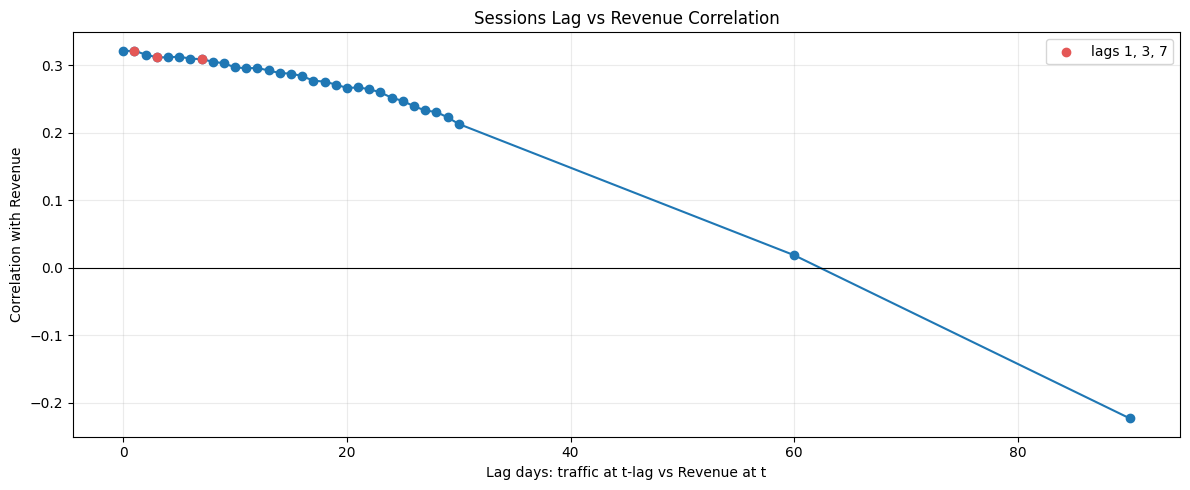

,lag_days,feature,correlation_with_revenue,valid_days
0,0,page_views,0.3016,3652
1,1,page_views,0.3055,3651
2,2,page_views,0.2949,3650
3,3,page_views,0.2846,3649
4,4,page_views,0.2872,3648
5,5,page_views,0.2863,3647
6,6,page_views,0.2835,3646
7,7,page_views,0.2865,3645
8,8,page_views,0.2822,3644
9,9,page_views,0.2735,3643


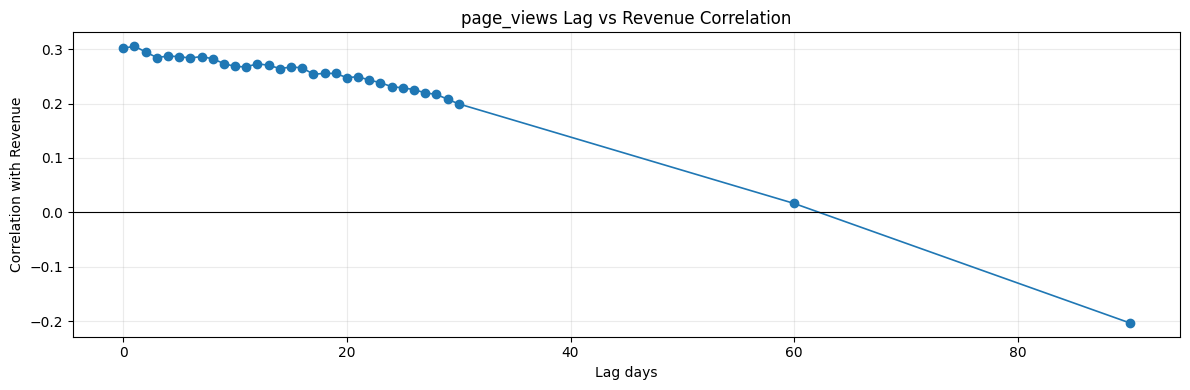

,lag_days,feature,correlation_with_revenue,valid_days
0,0,unique_visitors,0.3188,3652
1,1,unique_visitors,0.3185,3651
2,2,unique_visitors,0.3113,3650
3,3,unique_visitors,0.3046,3649
4,4,unique_visitors,0.3065,3648
5,5,unique_visitors,0.3093,3647
6,6,unique_visitors,0.3063,3646
7,7,unique_visitors,0.3073,3645
8,8,unique_visitors,0.3058,3644
9,9,unique_visitors,0.3029,3643


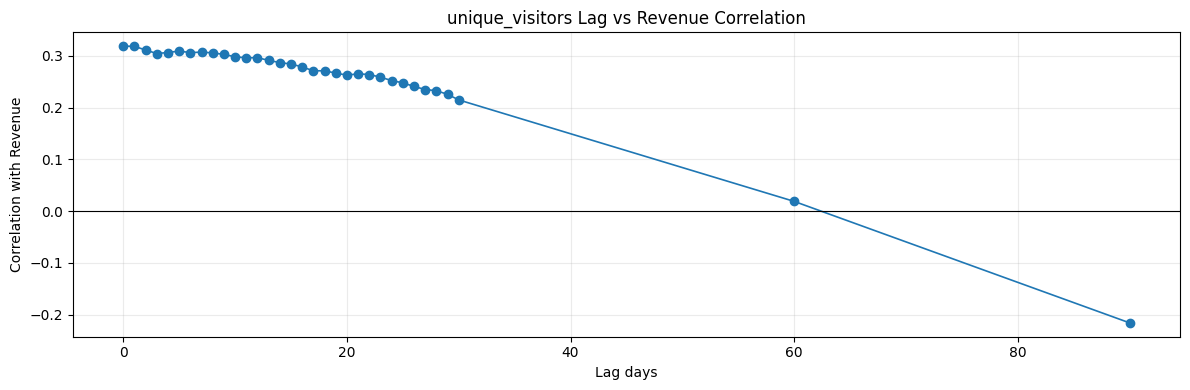

,lag_days,feature,correlation_with_revenue,valid_days
0,0,bounce_rate,-0.0206,3652
1,1,bounce_rate,-0.0173,3651
2,2,bounce_rate,-0.0016,3650
3,3,bounce_rate,0.0030,3649
4,4,bounce_rate,0.0070,3648
5,5,bounce_rate,0.0130,3647
6,6,bounce_rate,0.0025,3646
7,7,bounce_rate,-0.0146,3645
8,8,bounce_rate,-0.0158,3644
9,9,bounce_rate,-0.0138,3643


,lag_days,feature,correlation_with_revenue,valid_days
0,0,avg_session_duration,-0.0256,3652
1,1,avg_session_duration,-0.0214,3651
2,2,avg_session_duration,-0.0262,3650
3,3,avg_session_duration,-0.0087,3649
4,4,avg_session_duration,-0.0046,3648
5,5,avg_session_duration,-0.0004,3647
6,6,avg_session_duration,-0.0026,3646
7,7,avg_session_duration,-0.0069,3645
8,8,avg_session_duration,-0.0312,3644
9,9,avg_session_duration,-0.0342,3643


In [7]:
cross_corr_sessions = pd.DataFrame()
cross_corr_other = {}

def lag_corr_table(df, target_col, feature_col, lags):
    rows = []
    for lag in lags:
        feature_name = f'{feature_col}_lag_{lag}'
        shifted = df[feature_col].shift(lag)
        valid = pd.DataFrame({target_col: df[target_col], feature_name: shifted}).replace([np.inf, -np.inf], np.nan).dropna()
        corr = valid[target_col].corr(valid[feature_name]) if len(valid) >= 2 else np.nan
        rows.append({'lag_days': lag, 'feature': feature_col, 'correlation_with_revenue': corr, 'valid_days': len(valid)})
    return pd.DataFrame(rows)

if joined.empty or 'revenue' not in joined.columns or 'sessions' not in joined.columns:
    print('Joined Revenue and sessions data is unavailable; cross-correlation analysis cannot be computed.')
else:
    rel = joined.sort_values('date').copy()
    max_basic_lag = min(30, max(len(rel) - 2, 0))
    lags = list(range(0, max_basic_lag + 1))
    for extra_lag in [60, 90]:
        if len(rel) > extra_lag + 5:
            lags.append(extra_lag)
    lags = sorted(set(lags))

    cross_corr_sessions = lag_corr_table(rel, 'revenue', 'sessions', lags)
    display(cross_corr_sessions)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(cross_corr_sessions['lag_days'], cross_corr_sessions['correlation_with_revenue'], marker='o', linewidth=1.5)
    highlight = cross_corr_sessions[cross_corr_sessions['lag_days'].isin([1, 3, 7])]
    ax.scatter(highlight['lag_days'], highlight['correlation_with_revenue'], color='#E45756', zorder=3, label='lags 1, 3, 7')
    ax.set_title('Sessions Lag vs Revenue Correlation')
    ax.set_xlabel('Lag days: traffic at t-lag vs Revenue at t')
    ax.set_ylabel('Correlation with Revenue')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.legend()
    plt.tight_layout()
    plt.show()

    for metric in ['page_views', 'unique_visitors', 'bounce_rate', 'avg_session_duration']:
        if metric in rel.columns:
            tbl = lag_corr_table(rel, 'revenue', metric, lags)
            cross_corr_other[metric] = tbl
            display(tbl.head(35))
            if metric in ['page_views', 'unique_visitors']:
                fig, ax = plt.subplots(figsize=(12, 4))
                ax.plot(tbl['lag_days'], tbl['correlation_with_revenue'], marker='o', linewidth=1.2)
                ax.set_title(f'{metric} Lag vs Revenue Correlation')
                ax.set_xlabel('Lag days')
                ax.set_ylabel('Correlation with Revenue')
                ax.axhline(0, color='black', linewidth=0.8)
                plt.tight_layout()
                plt.show()

## 8. Selected Lag Correlation Table

Build a ranked table for selected lagged traffic features and highlight which historical signals appear strongest by absolute correlation.

In [8]:
selected_lag_corr = pd.DataFrame()
if joined.empty or 'revenue' not in joined.columns:
    print('Joined data is unavailable; selected lag table cannot be computed.')
else:
    rel = joined.sort_values('date').copy()
    feature_defs = [
        ('sessions_lag_0', 'sessions', 0),
        ('sessions_lag_1', 'sessions', 1),
        ('sessions_lag_3', 'sessions', 3),
        ('sessions_lag_7', 'sessions', 7),
        ('sessions_lag_14', 'sessions', 14),
        ('sessions_lag_30', 'sessions', 30),
    ]
    if 'page_views' in rel.columns:
        feature_defs.append(('page_views_lag_7', 'page_views', 7))
    if 'unique_visitors' in rel.columns:
        feature_defs.append(('unique_visitors_lag_7', 'unique_visitors', 7))
    if 'bounce_rate' in rel.columns:
        feature_defs.append(('bounce_rate_lag_7', 'bounce_rate', 7))
    if 'avg_session_duration' in rel.columns:
        feature_defs.append(('avg_session_duration_lag_7', 'avg_session_duration', 7))

    rows = []
    for feature_name, base_col, lag in feature_defs:
        if base_col not in rel.columns:
            continue
        shifted = rel[base_col].shift(lag)
        valid = pd.DataFrame({'revenue': rel['revenue'], feature_name: shifted}).replace([np.inf, -np.inf], np.nan).dropna()
        rows.append({
            'feature': feature_name,
            'base_metric': base_col,
            'lag_days': lag,
            'correlation_with_revenue': valid['revenue'].corr(valid[feature_name]) if len(valid) >= 2 else np.nan,
            'abs_correlation': abs(valid['revenue'].corr(valid[feature_name])) if len(valid) >= 2 and pd.notna(valid['revenue'].corr(valid[feature_name])) else np.nan,
            'valid_days': len(valid),
        })
    selected_lag_corr = pd.DataFrame(rows).sort_values('abs_correlation', ascending=False)
    display(selected_lag_corr)

,feature,base_metric,lag_days,correlation_with_revenue,abs_correlation,valid_days
1,sessions_lag_1,sessions,1,0.3216,0.3216,3651
0,sessions_lag_0,sessions,0,0.3211,0.3211,3652
2,sessions_lag_3,sessions,3,0.3119,0.3119,3649
3,sessions_lag_7,sessions,7,0.3092,0.3092,3645
7,unique_visitors_lag_7,unique_visitors,7,0.3073,0.3073,3645
4,sessions_lag_14,sessions,14,0.2885,0.2885,3638
6,page_views_lag_7,page_views,7,0.2865,0.2865,3645
5,sessions_lag_30,sessions,30,0.2132,0.2132,3622
8,bounce_rate_lag_7,bounce_rate,7,-0.0146,0.0146,3645
9,avg_session_duration_lag_7,avg_session_duration,7,-0.0069,0.0069,3645


## 9. Scatter Plots for Lagged Traffic

Plot Revenue against selected session lags. A simple fitted line is added as a visual guide only.

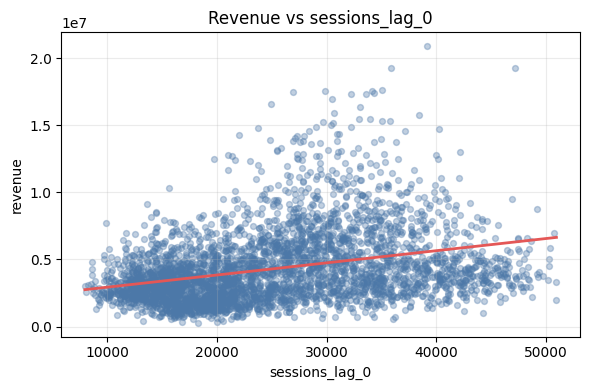

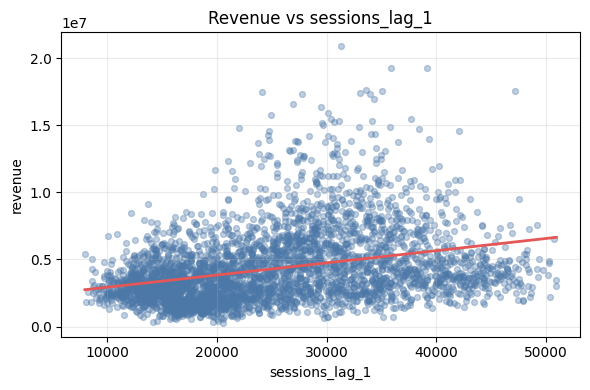

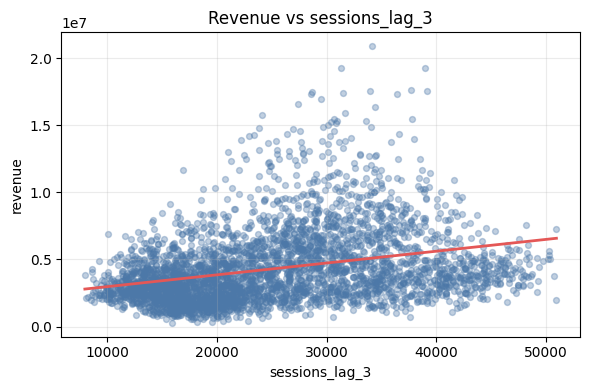

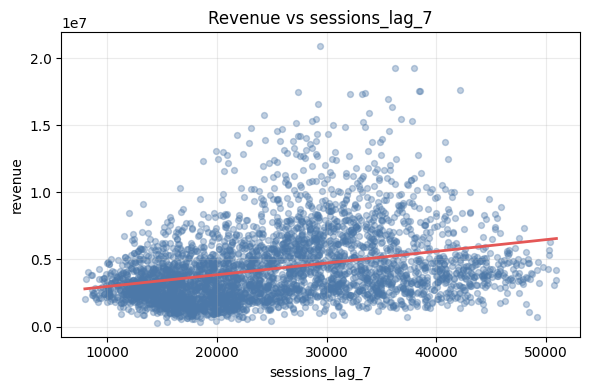

In [9]:
def scatter_with_fit(df, x_col, y_col, title):
    sample = df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    if sample.empty:
        print(f'No valid data for {title}.')
        return
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(sample[x_col], sample[y_col], alpha=0.35, s=18, color='#4C78A8')
    if len(sample) >= 2 and sample[x_col].nunique() > 1:
        coeff = np.polyfit(sample[x_col], sample[y_col], 1)
        x_line = np.linspace(sample[x_col].min(), sample[x_col].max(), 100)
        y_line = coeff[0] * x_line + coeff[1]
        ax.plot(x_line, y_line, color='#E45756', linewidth=2)
    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    plt.tight_layout()
    plt.show()

if joined.empty or 'revenue' not in joined.columns or 'sessions' not in joined.columns:
    print('Joined Revenue and sessions data is unavailable; scatter plots cannot be computed.')
else:
    rel = joined.sort_values('date').copy()
    for lag in [0, 1, 3, 7]:
        col = f'sessions_lag_{lag}'
        rel[col] = rel['sessions'].shift(lag)
        scatter_with_fit(rel, col, 'revenue', f'Revenue vs {col}')

## 10. Rolling Correlation Analysis

Compute rolling correlations between Revenue and selected session lags to assess whether the relationship is stable or changes over time.

,date,revenue,sessions_lag_0,sessions_lag_1,sessions_lag_7,roll_corr_sessions_lag_0,roll_corr_sessions_lag_1,roll_corr_sessions_lag_7
3813,2022-12-12,"1,983,085.0600","20,895.0000","20,104.0000","24,621.0000",0.4114,0.4328,0.3749
3814,2022-12-13,"1,652,309.1900","18,678.0000","20,895.0000","21,837.0000",0.4256,0.4405,0.3784
3815,2022-12-14,"1,662,243.5900","19,332.0000","18,678.0000","21,436.0000",0.4182,0.4299,0.3719
3816,2022-12-15,"1,494,318.6400","20,742.0000","19,332.0000","22,392.0000",0.4152,0.4295,0.3664
3817,2022-12-16,"1,482,192.9700","21,729.0000","20,742.0000","18,315.0000",0.4228,0.4371,0.3823
3818,2022-12-17,"1,302,193.7400","21,209.0000","21,729.0000","21,589.0000",0.4196,0.4339,0.3833
3819,2022-12-18,"2,201,374.5900","22,512.0000","21,209.0000","20,104.0000",0.4125,0.4291,0.3752
3820,2022-12-19,"2,250,767.3900","20,265.0000","22,512.0000","20,895.0000",0.4301,0.4458,0.3875
3821,2022-12-20,"2,026,810.0800","23,389.0000","20,265.0000","18,678.0000",0.4345,0.4528,0.3933
3822,2022-12-21,"1,795,395.0200","19,702.0000","23,389.0000","19,332.0000",0.4219,0.4360,0.3848


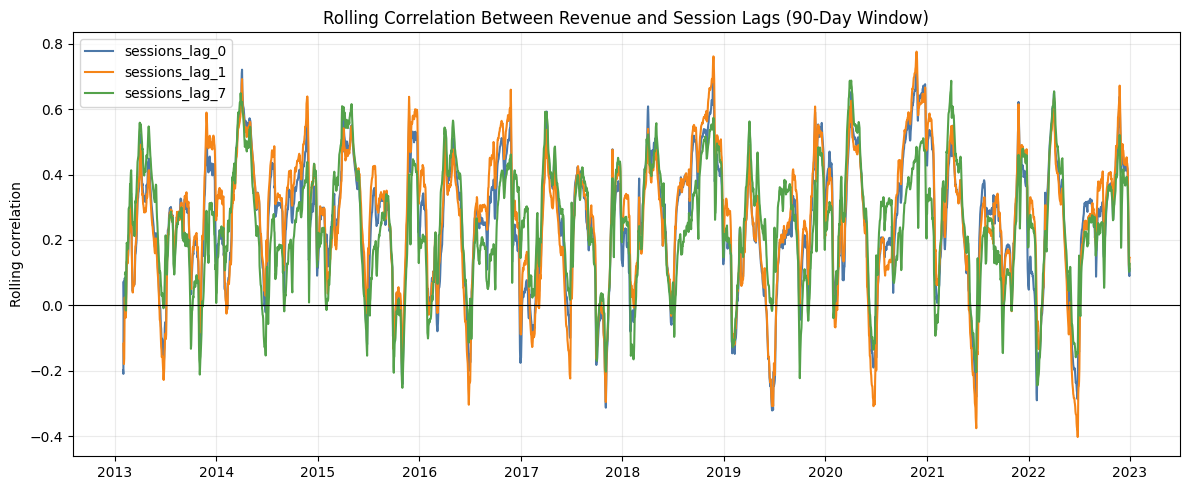

In [10]:
rolling_corr = pd.DataFrame()
if joined.empty or 'revenue' not in joined.columns or 'sessions' not in joined.columns:
    print('Joined Revenue and sessions data is unavailable; rolling correlation cannot be computed.')
else:
    rel = joined.sort_values('date').copy()
    rel['sessions_lag_0'] = rel['sessions']
    rel['sessions_lag_1'] = rel['sessions'].shift(1)
    rel['sessions_lag_7'] = rel['sessions'].shift(7)
    rolling_corr = rel[['date', 'revenue', 'sessions_lag_0', 'sessions_lag_1', 'sessions_lag_7']].copy()
    window = 90 if len(rel) >= 180 else (60 if len(rel) >= 120 else 30)
    for col in ['sessions_lag_0', 'sessions_lag_1', 'sessions_lag_7']:
        rolling_corr[f'roll_corr_{col}'] = rolling_corr['revenue'].rolling(window, min_periods=max(10, window // 3)).corr(rolling_corr[col])
    display(rolling_corr.tail(20))

    fig, ax = plt.subplots(figsize=(12, 5))
    for col, color in [('roll_corr_sessions_lag_0', '#4C78A8'), ('roll_corr_sessions_lag_1', '#F58518'), ('roll_corr_sessions_lag_7', '#54A24B')]:
        if col in rolling_corr.columns:
            ax.plot(rolling_corr['date'], rolling_corr[col], label=col.replace('roll_corr_', ''), color=color)
    ax.set_title(f'Rolling Correlation Between Revenue and Session Lags ({window}-Day Window)')
    ax.set_ylabel('Rolling correlation')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.legend()
    plt.tight_layout()
    plt.show()

## 11. Traffic Spike Followed by Revenue Response

Detect traffic spike days and check whether Revenue is unusually high on the same day, 1 day later, 3 days later, or 7 days later.

,date,sessions,session_spike_z_score,revenue_same_day,revenue_spike_same_day,revenue_plus_1d,revenue_spike_plus_1d,revenue_plus_3d,revenue_spike_plus_3d,revenue_plus_7d,revenue_spike_plus_7d
177,2022-06-26,"50,947.0000",2.7496,"3,313,898.5500",False,"3,481,464.6800",False,"7,265,484.4900",False,"3,487,232.0000",False
125,2022-04-04,"50,915.0000",2.7462,"1,974,536.5500",False,"3,017,582.3000",False,"1,947,894.5800",False,"4,187,283.4000",False
87,2021-04-30,"50,714.0000",2.7249,"6,962,149.3300",False,"6,555,221.4900",False,"3,778,243.0200",False,"3,099,539.7500",False
157,2022-05-19,"50,386.0000",2.6901,"5,824,908.1800",False,"2,226,534.2000",False,"5,000,275.7400",False,"6,284,218.4900",False
83,2021-04-25,"50,274.0000",2.6782,"4,545,990.2900",False,"4,718,077.1100",False,"5,606,431.4900",False,"5,301,495.0700",False
142,2022-04-24,"50,247.0000",2.6753,"5,020,542.9900",False,"4,873,788.4200",False,"5,361,513.7600",False,"5,680,859.4400",False
114,2021-06-21,"50,225.0000",2.6730,"3,454,322.4500",False,"3,814,525.8100",False,"5,015,283.2600",False,"4,255,543.9600",False
130,2022-04-10,"49,768.0000",2.6245,"3,747,690.9300",False,"4,187,283.4000",False,"4,888,627.3100",False,"4,470,361.3800",False
158,2022-05-21,"49,387.0000",2.5841,"4,033,154.2800",False,"5,000,275.7400",False,"4,442,598.3600",False,"3,223,975.8400",False
165,2022-06-07,"49,231.0000",2.5675,"3,673,238.8000",False,"3,686,799.9000",False,"3,369,544.0100",False,"4,843,640.7600",False


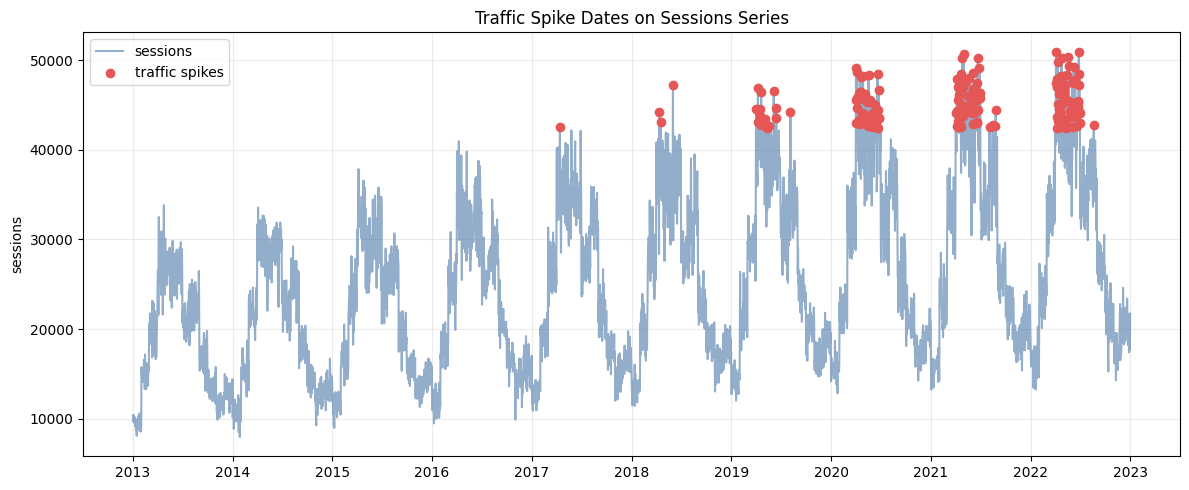

In [11]:
spike_followup = pd.DataFrame()
if joined.empty or 'revenue' not in joined.columns or 'sessions' not in joined.columns:
    print('Joined Revenue and sessions data is unavailable; spike follow-up analysis cannot be computed.')
else:
    rel = joined.sort_values('date').copy()
    sessions = rel['sessions'].astype(float)
    mean = sessions.mean()
    std = sessions.std(ddof=0)
    q1, q3 = sessions.quantile([0.25, 0.75])
    iqr = q3 - q1
    p95 = sessions.quantile(0.95)
    z = (sessions - mean) / std if std != 0 else pd.Series(0, index=sessions.index)
    spike_flag = (z >= 3) | (sessions >= q3 + 1.5 * iqr) | (sessions >= p95)

    revenue_threshold = max(rel['revenue'].quantile(0.95), rel['revenue'].mean() + 3 * rel['revenue'].std(ddof=0))
    rel['revenue_spike'] = rel['revenue'] >= revenue_threshold
    rows = []
    for idx, row in rel.loc[spike_flag].iterrows():
        out = {
            'date': row['date'],
            'sessions': row['sessions'],
            'session_spike_z_score': z.loc[idx],
            'revenue_same_day': row['revenue'],
            'revenue_spike_same_day': bool(row['revenue_spike']),
        }
        for lag in [1, 3, 7]:
            future_row = rel.loc[rel['date'] == row['date'] + pd.Timedelta(days=lag)]
            if not future_row.empty:
                out[f'revenue_plus_{lag}d'] = future_row['revenue'].iloc[0]
                out[f'revenue_spike_plus_{lag}d'] = bool(future_row['revenue_spike'].iloc[0])
            else:
                out[f'revenue_plus_{lag}d'] = np.nan
                out[f'revenue_spike_plus_{lag}d'] = pd.NA
        rows.append(out)
    spike_followup = pd.DataFrame(rows).sort_values('sessions', ascending=False)
    display(spike_followup.head(50))

    if not spike_followup.empty:
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(rel['date'], rel['sessions'], color='#4C78A8', alpha=0.6, label='sessions')
        ax.scatter(spike_followup['date'], spike_followup['sessions'], color='#E45756', zorder=3, label='traffic spikes')
        ax.set_title('Traffic Spike Dates on Sessions Series')
        ax.set_ylabel('sessions')
        ax.legend()
        plt.tight_layout()
        plt.show()

## 12. Leakage-Safe Lagged Traffic Feature Preview

Create lagged traffic feature candidates that use only traffic observed before the Revenue date. Same-day traffic is shown separately because it requires that traffic be known before prediction.

In [12]:
feature_preview = pd.DataFrame()
feature_registry = pd.DataFrame()
if joined.empty or 'revenue' not in joined.columns:
    print('Joined traffic and Revenue data is unavailable; feature preview cannot be built.')
else:
    feature_preview = joined.sort_values('date').copy()
    if 'sessions' in feature_preview.columns:
        for lag in [1, 3, 7, 14, 30]:
            feature_preview[f'sessions_lag_{lag}'] = feature_preview['sessions'].shift(lag)
        feature_preview['sessions_roll_mean_7_lagged'] = feature_preview['sessions'].shift(1).rolling(7, min_periods=3).mean()
        feature_preview['sessions_roll_mean_30_lagged'] = feature_preview['sessions'].shift(1).rolling(30, min_periods=7).mean()
    if 'page_views' in feature_preview.columns:
        feature_preview['page_views_lag_7'] = feature_preview['page_views'].shift(7)
    if 'unique_visitors' in feature_preview.columns:
        feature_preview['unique_visitors_lag_7'] = feature_preview['unique_visitors'].shift(7)
    if 'bounce_rate' in feature_preview.columns:
        feature_preview['bounce_rate_lag_7'] = feature_preview['bounce_rate'].shift(7)
    if 'avg_session_duration' in feature_preview.columns:
        feature_preview['avg_session_duration_lag_7'] = feature_preview['avg_session_duration'].shift(7)

    preview_cols = ['date', 'revenue']
    for c in ['sessions', 'page_views', 'unique_visitors', 'bounce_rate', 'avg_session_duration',
              'sessions_lag_1', 'sessions_lag_3', 'sessions_lag_7', 'sessions_lag_14', 'sessions_lag_30',
              'page_views_lag_7', 'unique_visitors_lag_7', 'bounce_rate_lag_7', 'avg_session_duration_lag_7',
              'sessions_roll_mean_7_lagged', 'sessions_roll_mean_30_lagged']:
        if c in feature_preview.columns:
            preview_cols.append(c)
    display(feature_preview[preview_cols].head(40))

    known_same_day = [c for c in ['sessions', 'page_views', 'unique_visitors', 'bounce_rate', 'avg_session_duration'] if c in feature_preview.columns]
    historical_safe = [c for c in feature_preview.columns if c.endswith('_lag_1') or c.endswith('_lag_3') or c.endswith('_lag_7') or c.endswith('_lag_14') or c.endswith('_lag_30') or c.endswith('_lagged')]
    feature_registry = pd.DataFrame({
        'feature': known_same_day + historical_safe,
        'feature_type': ['requires known same-day traffic'] * len(known_same_day) + ['historical lag/rolling only'] * len(historical_safe),
        'forecast_use_note': ['Use only if this same-day traffic value is genuinely known before prediction.'] * len(known_same_day) + ['Leakage-safe candidate because it uses only prior observed traffic.'] * len(historical_safe),
    }).drop_duplicates()
    display(feature_registry)

,date,revenue,sessions,page_views,unique_visitors,bounce_rate,avg_session_duration,sessions_lag_1,sessions_lag_3,sessions_lag_7,sessions_lag_14,sessions_lag_30,page_views_lag_7,unique_visitors_lag_7,bounce_rate_lag_7,avg_session_duration_lag_7,sessions_roll_mean_7_lagged,sessions_roll_mean_30_lagged
0,2012-07-04,"5,123,547.9400",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,"2,751,773.4500",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-07-06,"3,054,029.4200",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2012-07-07,"2,667,930.9400",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2012-07-08,"2,360,851.9000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2012-07-09,"3,548,386.4600",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2012-07-10,"5,234,938.6200",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2012-07-11,"5,582,884.7800",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2012-07-12,"5,734,632.0200",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2012-07-13,"5,309,511.7100",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,feature,feature_type,forecast_use_note
0,sessions,requires known same-day traffic,Use only if this same-day traffic value is gen...
1,page_views,requires known same-day traffic,Use only if this same-day traffic value is gen...
2,unique_visitors,requires known same-day traffic,Use only if this same-day traffic value is gen...
3,bounce_rate,requires known same-day traffic,Use only if this same-day traffic value is gen...
4,avg_session_duration,requires known same-day traffic,Use only if this same-day traffic value is gen...
5,sessions_lag_1,historical lag/rolling only,Leakage-safe candidate because it uses only pr...
6,sessions_lag_3,historical lag/rolling only,Leakage-safe candidate because it uses only pr...
7,sessions_lag_7,historical lag/rolling only,Leakage-safe candidate because it uses only pr...
8,sessions_lag_14,historical lag/rolling only,Leakage-safe candidate because it uses only pr...
9,sessions_lag_30,historical lag/rolling only,Leakage-safe candidate because it uses only pr...


## 13. Key Observations and Warnings

Final concise summary with strongest lag relationships, rolling stability, spike follow-up signals, recommended features, and leakage cautions.

In [13]:
def fmt(x, digits=4):
    return 'n/a' if pd.isna(x) else f'{x:,.{digits}f}'

summary_lines = []

if not selected_lag_corr.empty:
    best_sessions = selected_lag_corr[selected_lag_corr['base_metric'].eq('sessions')].sort_values('abs_correlation', ascending=False).head(1)
    if not best_sessions.empty:
        r = best_sessions.iloc[0]
        summary_lines.append(f"Strongest sessions lag correlation with Revenue: {r['feature']} at {fmt(r['correlation_with_revenue'], 4)}.")
    lag_1 = selected_lag_corr[selected_lag_corr['feature'].eq('sessions_lag_1')]['correlation_with_revenue']
    lag_3 = selected_lag_corr[selected_lag_corr['feature'].eq('sessions_lag_3')]['correlation_with_revenue']
    lag_7 = selected_lag_corr[selected_lag_corr['feature'].eq('sessions_lag_7')]['correlation_with_revenue']
    lag_parts = []
    if not lag_1.empty:
        lag_parts.append(f"lag 1={lag_1.iloc[0]:.4f}")
    if not lag_3.empty:
        lag_parts.append(f"lag 3={lag_3.iloc[0]:.4f}")
    if not lag_7.empty:
        lag_parts.append(f"lag 7={lag_7.iloc[0]:.4f}")
    if lag_parts:
        summary_lines.append('Sessions lag usefulness snapshot: ' + ', '.join(lag_parts) + '.')
else:
    summary_lines.append('Lagged traffic correlations could not be computed because joined traffic and Revenue data was unavailable.')

if not cross_corr_sessions.empty:
    best_overall = cross_corr_sessions.dropna(subset=['correlation_with_revenue']).iloc[cross_corr_sessions['correlation_with_revenue'].abs().argmax()]
    lag0_row = cross_corr_sessions[cross_corr_sessions['lag_days'].eq(0)]
    if not lag0_row.empty:
        lag0_corr = lag0_row['correlation_with_revenue'].iloc[0]
        relation = 'lagged traffic' if abs(best_overall['correlation_with_revenue']) > abs(lag0_corr) and best_overall['lag_days'] != 0 else 'same-day traffic'
        summary_lines.append(f"Same-day sessions correlation is {fmt(lag0_corr, 4)}; best sessions cross-correlation is lag {int(best_overall['lag_days'])} at {fmt(best_overall['correlation_with_revenue'], 4)}. {relation} appears more aligned under this correlation view.")

if cross_corr_other:
    other_parts = []
    for metric, tbl in cross_corr_other.items():
        valid_tbl = tbl.dropna(subset=['correlation_with_revenue'])
        if not valid_tbl.empty:
            best = valid_tbl.iloc[valid_tbl['correlation_with_revenue'].abs().argmax()]
            other_parts.append(f"{metric}: lag {int(best['lag_days'])} corr {best['correlation_with_revenue']:.4f}")
    if other_parts:
        summary_lines.append('Other lagged traffic signals: ' + '; '.join(other_parts) + '.')

if not rolling_corr.empty:
    roll_cols = [c for c in rolling_corr.columns if c.startswith('roll_corr_')]
    stability_parts = []
    for c in roll_cols:
        series = rolling_corr[c].dropna()
        if not series.empty:
            sign_changes = int((np.sign(series).diff().fillna(0) != 0).sum())
            spread = series.max() - series.min()
            stability = 'unstable' if sign_changes > 3 or spread > 0.5 else 'relatively stable'
            stability_parts.append(f"{c.replace('roll_corr_', '')}: {stability}, range {series.min():.3f} to {series.max():.3f}")
    if stability_parts:
        summary_lines.append('Rolling correlation behavior: ' + '; '.join(stability_parts) + '.')

if not spike_followup.empty:
    same_day = int(spike_followup['revenue_spike_same_day'].fillna(False).sum())
    plus1 = int(spike_followup['revenue_spike_plus_1d'].fillna(False).sum()) if 'revenue_spike_plus_1d' in spike_followup else 0
    plus3 = int(spike_followup['revenue_spike_plus_3d'].fillna(False).sum()) if 'revenue_spike_plus_3d' in spike_followup else 0
    plus7 = int(spike_followup['revenue_spike_plus_7d'].fillna(False).sum()) if 'revenue_spike_plus_7d' in spike_followup else 0
    examples = spike_followup[(spike_followup.get('revenue_spike_plus_1d', False) == True) | (spike_followup.get('revenue_spike_plus_3d', False) == True) | (spike_followup.get('revenue_spike_plus_7d', False) == True)].head(5)
    summary_lines.append(f"Traffic spikes followed by Revenue spike flags: same day={same_day}, +1 day={plus1}, +3 days={plus3}, +7 days={plus7}.")
    if not examples.empty:
        summary_lines.append('Example traffic spikes with later Revenue spike flags: ' + ', '.join(str(pd.Timestamp(d).date()) for d in examples['date'].tolist()) + '.')

if traffic_warnings:
    summary_lines.append('Traffic warnings: ' + '; '.join(traffic_warnings))
if sales_warnings:
    summary_lines.append('Sales warnings: ' + '; '.join(sales_warnings))

summary_lines.append('Recommended lagged traffic forecast features: sessions_lag_1, sessions_lag_3, sessions_lag_7, sessions_lag_14, sessions_lag_30, page_views_lag_7, unique_visitors_lag_7, bounce_rate_lag_7, avg_session_duration_lag_7, sessions_roll_mean_7_lagged, and sessions_roll_mean_30_lagged.')
summary_lines.append('Leakage warning: future or same-day traffic must not be used directly unless it is known before prediction. Otherwise forecast traffic first or use historical lagged traffic features only.')
summary_lines.append('Causal caution: this is observational EDA. Traffic and Revenue can move together because of seasonality, promotions, campaign timing, assortment, and stock availability.')

print('KEY OBSERVATIONS AND WARNINGS')
for line in summary_lines:
    print('-', line)

KEY OBSERVATIONS AND WARNINGS
- Strongest sessions lag correlation with Revenue: sessions_lag_1 at 0.3216.
- Sessions lag usefulness snapshot: lag 1=0.3216, lag 3=0.3119, lag 7=0.3092.
- Same-day sessions correlation is 0.3211; best sessions cross-correlation is lag 1 at 0.3216. lagged traffic appears more aligned under this correlation view.
- Other lagged traffic signals: page_views: lag 1 corr 0.3055; unique_visitors: lag 0 corr 0.3188; bounce_rate: lag 26 corr -0.0371; avg_session_duration: lag 9 corr -0.0342.
- Rolling correlation behavior: sessions_lag_0: unstable, range -0.321 to 0.731; sessions_lag_1: unstable, range -0.402 to 0.776; sessions_lag_7: unstable, range -0.252 to 0.687.
- Traffic spikes followed by Revenue spike flags: same day=1, +1 day=1, +3 days=0, +7 days=0.
- Example traffic spikes with later Revenue spike flags: 2018-06-01.
- Recommended lagged traffic forecast features: sessions_lag_1, sessions_lag_3, sessions_lag_7, sessions_lag_14, sessions_lag_30, page_vie